# Subject 01 retinotopic maps

This notebook visualizes the processed **polar-angle** and **eccentricity** maps from the StudyForrest retinotopic-mapping derivative.

Each NIfTI has two volumes: volume 0 contains phase values in degrees (0–360°), and volume 1 contains the corresponding response-strength values. The phase maps are masked using the response threshold below. A cyclic `hsv` color map is used because 0° and 360° represent the same phase.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from nilearn import image, plotting

## Paths and plotting parameters

Increase `response_threshold` for a more conservative map, or decrease it to display more voxels.

In [2]:
map_dir = Path(
    "studyforrest-data/derivative/retinotopic_maps/"
    "sub-01/post_processing"
)
polar_path = map_dir / "combined_pipeline_polar.nii.gz"
eccentricity_path = map_dir / "combined_pipeline_eccentricity.nii.gz"

response_threshold = 0.40
posterior_y_cuts = [-120, -110, -100, -90, -80, -70]
polar_output = Path("sub-01_retinotopy_polar-angle.png")
eccentricity_output = Path("sub-01_retinotopy_eccentricity.png")

## Load and threshold the maps

In [3]:
def load_phase_map(path, threshold):
    """Return a response-masked 3D phase image and summary information."""
    img = nib.load(path)
    if len(img.shape) != 4 or img.shape[3] < 2:
        raise ValueError(f"Expected a 4D map with at least 2 volumes: {path}")

    phase_img = image.index_img(img, 0)
    response_img = image.index_img(img, 1)
    phase = np.asarray(phase_img.dataobj, dtype=np.float32)
    response = np.asarray(response_img.dataobj, dtype=np.float32)

    # Fill excluded voxels with zero; the plotting threshold below hides them.
    masked_phase = np.where(response >= threshold, phase, 0.0)
    masked_img = image.new_img_like(phase_img, masked_phase)
    return img, masked_img, response


polar_4d, polar_map, polar_response = load_phase_map(
    polar_path, response_threshold
)
eccentricity_4d, eccentricity_map, eccentricity_response = load_phase_map(
    eccentricity_path, response_threshold
)

print(f"Polar map shape: {polar_4d.shape}")
print(f"Eccentricity map shape: {eccentricity_4d.shape}")
print(f"Voxel size: {polar_4d.header.get_zooms()[:3]} mm")
print(f"Response threshold: {response_threshold:.2f}")
print(f"Polar responsive voxels: {(polar_response >= response_threshold).sum():,}")
print(
    "Eccentricity responsive voxels: "
    f"{(eccentricity_response >= response_threshold).sum():,}"
)

Polar map shape: (64, 86, 45, 2)
Eccentricity map shape: (64, 86, 45, 2)
Voxel size: (2.5, 2.5, 2.5) mm
Response threshold: 0.40
Polar responsive voxels: 14,307
Eccentricity responsive voxels: 17,206


## Polar-angle phase map

Coronal cuts progress through posterior visual cortex. Hue represents phase angle from 0° to 360°.

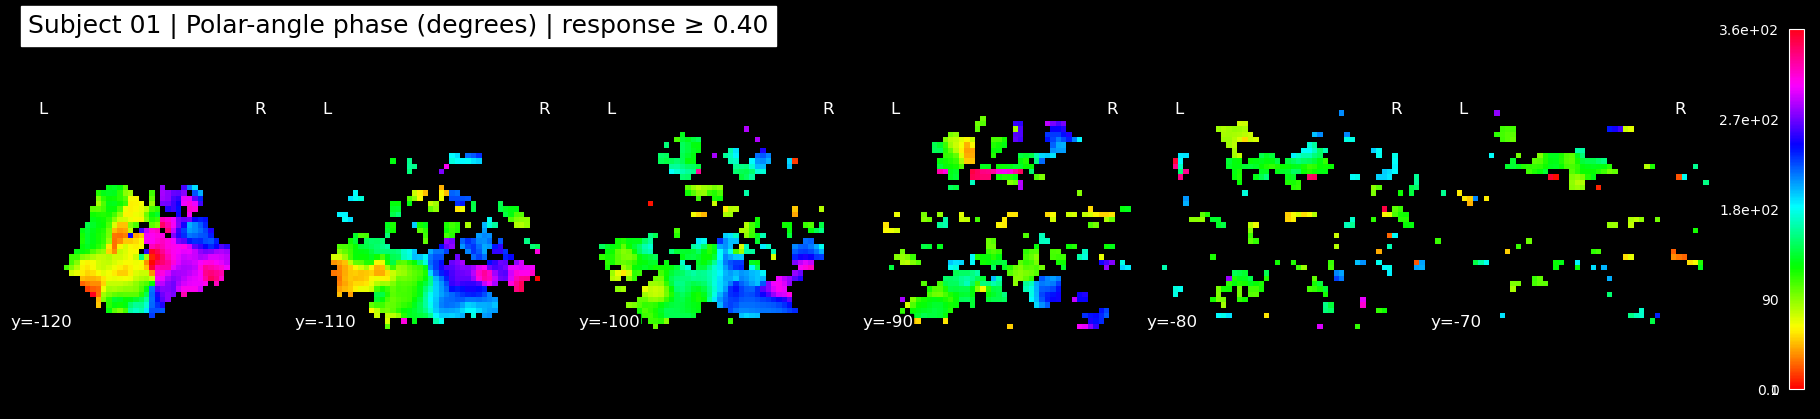

Saved: /home/jovyan/junruz/forrestgump/sub-01_retinotopy_polar-angle.png


In [4]:
polar_figure = plt.figure(figsize=(18, 4), facecolor="black")
polar_display = plotting.plot_stat_map(
    polar_map,
    bg_img=None,
    figure=polar_figure,
    display_mode="y",
    cut_coords=posterior_y_cuts,
    cmap="hsv",
    vmin=0,
    vmax=360,
    symmetric_cbar=False,
    threshold=0.1,
    colorbar=True,
    black_bg=True,
    annotate=True,
    draw_cross=False,
)
polar_display.title(
    "Subject 01 | Polar-angle phase (degrees) | "
    f"response ≥ {response_threshold:.2f}",
    color="black",
    bgcolor="white",
    size=18,
)
polar_display.savefig(polar_output, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {polar_output.resolve()}")

## Eccentricity phase map

The eccentricity derivative is also encoded as 0–360° stimulus phase.

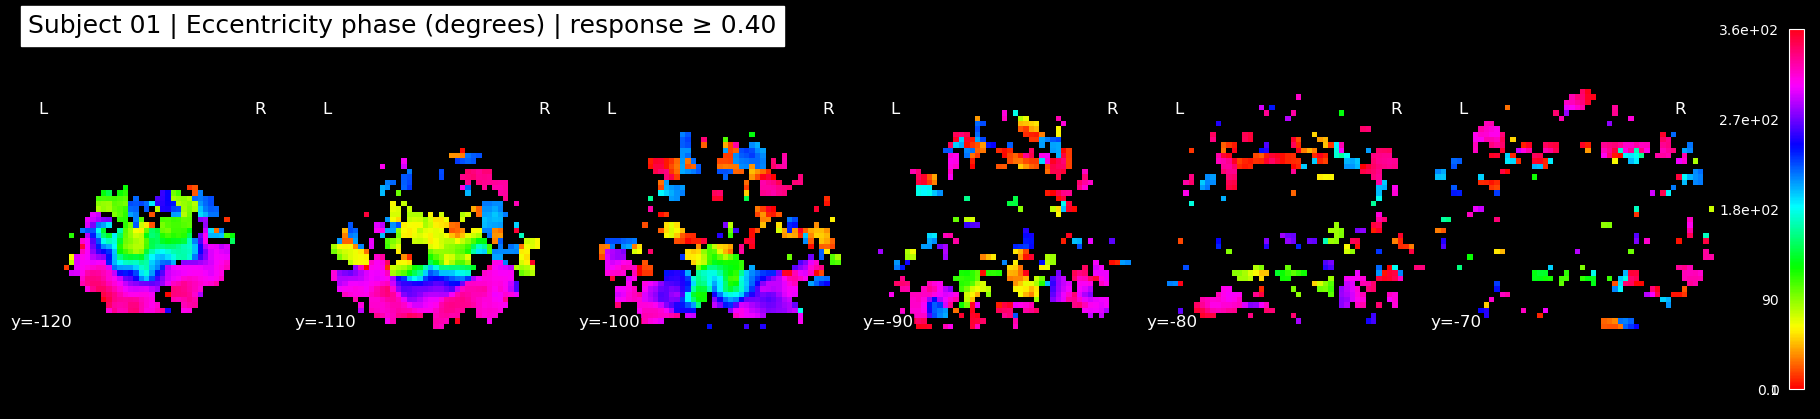

Saved: /home/jovyan/junruz/forrestgump/sub-01_retinotopy_eccentricity.png


In [5]:
eccentricity_figure = plt.figure(figsize=(18, 4), facecolor="black")
eccentricity_display = plotting.plot_stat_map(
    eccentricity_map,
    bg_img=None,
    figure=eccentricity_figure,
    display_mode="y",
    cut_coords=posterior_y_cuts,
    cmap="hsv",
    vmin=0,
    vmax=360,
    symmetric_cbar=False,
    threshold=0.1,
    colorbar=True,
    black_bg=True,
    annotate=True,
    draw_cross=False,
)
eccentricity_display.title(
    "Subject 01 | Eccentricity phase (degrees) | "
    f"response ≥ {response_threshold:.2f}",
    color="black",
    bgcolor="white",
    size=18,
)
eccentricity_display.savefig(
    eccentricity_output, dpi=180, bbox_inches="tight"
)
plt.show()
print(f"Saved: {eccentricity_output.resolve()}")